In [1]:
import numpy as np

dem_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/raw/DEM.npz"
mask_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/raw/Mounds_raster_mask_opened_closed.npy"

data = np.load(dem_path)
dem = data["dataset"].astype(np.float32)
valid = data["validMask"].astype(bool)
mask = np.load(mask_path).astype(np.uint8)

In [16]:
import numpy as np

dem_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/raw/DEM21_opt.npz"

data = np.load(dem_path)
dem = data["dataset"].astype(np.float32)
valid = data["validMask"].astype(bool)

In [19]:
dem_norm = np.zeros_like(dem)
print(np.unique(valid))
dem_norm[dem == 0] = -1
valid[dem_norm == -1] = False

print(dem_norm.shape)
print(valid.shape)
print(np.unique(valid))

[ True]
(34995, 22003)
(34995, 22003)
[False  True]


In [20]:
dem_norm = np.zeros_like(dem)

dem_norm[valid] = (dem[valid] - dem[valid].min()) / (dem[valid].max() - dem[valid].min())
dem_norm[~valid] = -1

print(dem.shape)
print(dem_norm.shape)
print(dem_norm.min(), dem_norm.max())
print(dem_norm[valid].min(), dem_norm[valid].max())

(34995, 22003)
(34995, 22003)
-1.0 1.0
0.0 1.0


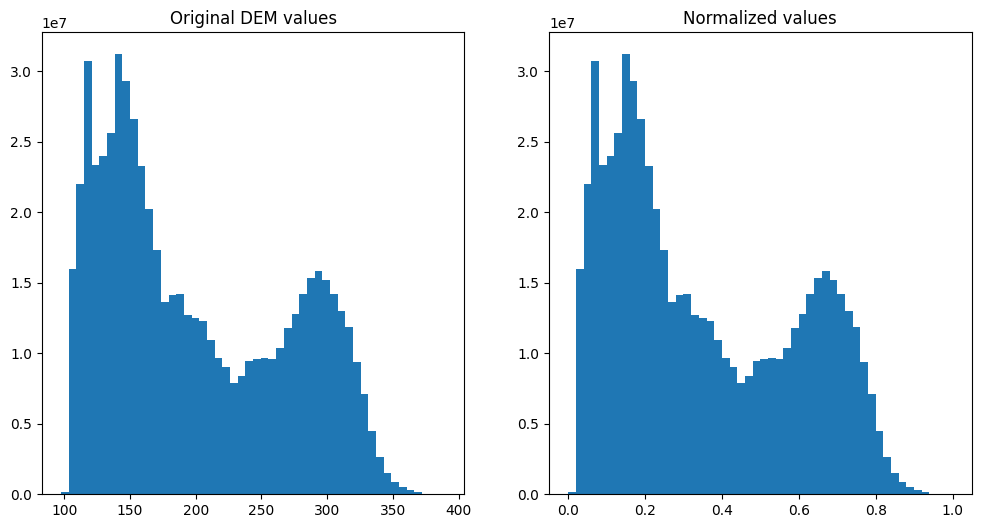

In [21]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.hist(dem[valid].ravel(), bins=50)
plt.title('Original DEM values')
plt.subplot(122)
plt.hist(dem_norm[valid].ravel(), bins=50)
plt.title('Normalized values')
plt.show()

In [4]:
n_samples = dem_norm.shape[0]
train_end = int(n_samples * 0.7)
val_end = train_end + int(n_samples * 0.15)
test_end = train_end + int(n_samples * 0.15)

train_data = dem_norm[:train_end]
val_data = dem_norm[train_end:val_end]
test_data = dem_norm[val_end:]

print(f"Total samples: {n_samples}")
print(f"Training set: {len(train_data)} samples ({len(train_data)/n_samples*100:.1f}%)")
print(f"Validation set: {len(val_data)} samples ({len(val_data)/n_samples*100:.1f}%)")
print(f"Test set: {len(test_data)} samples ({len(test_data)/n_samples*100:.1f}%)")

Total samples: 17092
Training set: 11964 samples (70.0%)
Validation set: 2563 samples (15.0%)
Test set: 2565 samples (15.0%)


In [22]:
to_save={
    "dem": dem_norm,
    "valid": valid
}

#np.savez_compressed("../data/processed/DEM_normalized.npz", **to_save)
np.savez_compressed("../data/processed/DEM21_opt_normalized.npz", **to_save)

In [6]:
from scipy.ndimage import distance_transform_edt

distance = distance_transform_edt(1 - mask) * 1

In [7]:
mask_shadowed = np.where(mask == 1, np.ones_like(distance), np.maximum(0, 1 - (distance / 4)))

In [8]:
mask_shadowed[~valid] = 0

In [9]:
np.unique(mask_shadowed)

array([0.        , 0.09861218, 0.20943058, 0.25      , 0.29289322,
       0.44098301, 0.5       , 0.64644661, 0.75      , 1.        ])

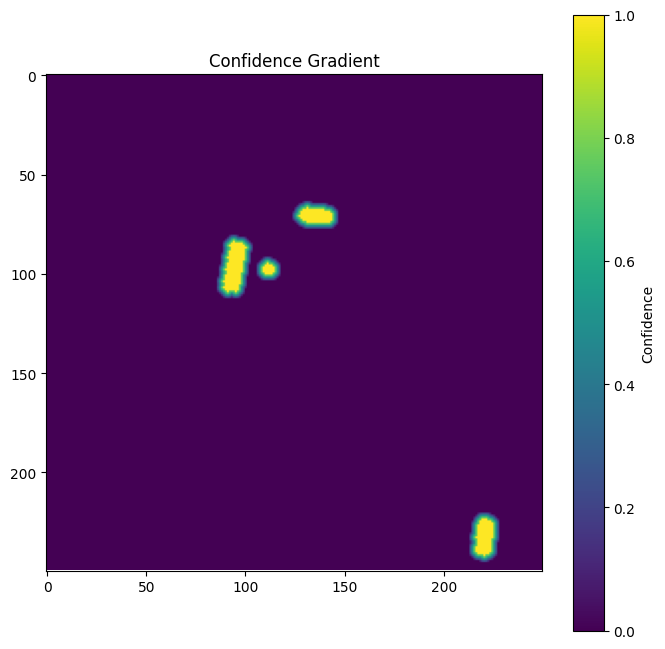

In [10]:
import matplotlib.pyplot as plt
    
patch = mask_shadowed[3000:3250, 3000:3250]
plt.figure(figsize=(8, 8))
plt.imshow(patch, cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='Confidence')
plt.title('Confidence Gradient')
plt.show()

In [11]:
np.save(
    "../data/processed/mounds_mask_shadowed.npy", 
    mask_shadowed
)

Train/Val/Test split

In [1]:
dem_normalized_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/processed/DEM_normalized.npz"
mask_shadowed_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/processed/mounds_mask_shadowed.npy"

In [2]:
import numpy as np

dem_normalized_data = np.load(dem_normalized_path)
mask = np.load(mask_shadowed_path)

dem = dem_normalized_data["dem"]
valid = dem_normalized_data["valid"]

In [14]:
print("DEM shape:", dem.shape)
print("DEM min:", dem[valid].min())
print("DEM max:", dem[valid].max())
print("DEM ignore_index:", dem.min())

DEM shape: (17092, 9791)
DEM min: 0.0
DEM max: 1.0
DEM ignore_index: -1.0


In [15]:
h, w = dem.shape
print(f"DEM shape: {dem.shape}")

train_end = int(0.7 * h)
val_end = train_end + int(0.15 * h)

# Split
dem_train = dem[:train_end, :]
dem_val = dem[train_end:val_end, :]
dem_test = dem[val_end:, :]

valid_train = valid[:train_end, :]
valid_val = valid[train_end:val_end, :]
valid_test = valid[val_end:, :]

mask_train = mask[:train_end, :]
mask_val = mask[train_end:val_end, :]
mask_test = mask[val_end:, :]

# Tests
assert dem_train.shape[0] + dem_val.shape[0] + dem_test.shape[0] == h
assert valid_train.shape[0] + valid_val.shape[0] + valid_test.shape[0] == h
assert mask_train.shape[0] + mask_val.shape[0] + mask_test.shape[0] == h
assert dem_train.shape == valid_train.shape == mask_train.shape

DEM shape: (17092, 9791)


In [16]:
import os
save_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/processed/"

dem_train = {"dem": dem_train, "valid": valid_train}
dem_val   = {"dem": dem_val, "valid": valid_val}
dem_test  = {"dem": dem_test, "valid": valid_test}

np.savez_compressed("../data/processed/DEM_normalized_train.npz", **dem_train)
np.savez_compressed("../data/processed/DEM_normalized_val.npz", **dem_val)
np.savez_compressed("../data/processed/DEM_normalized_test.npz", **dem_test)

np.save("../data/processed/mounds_mask_shadowed_train.npy", mask_train)
np.save("../data/processed/mounds_mask_shadowed_val.npy", mask_val)
np.save("../data/processed/mounds_mask_shadowed_test.npy", mask_test)

In [ ]:
import rasterio
from rasterio.windows import Window

# Source file
src_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/georef/DEM.tif"

with rasterio.open(src_path) as src:
    height = src.height
    width = src.width

    train_end = int(0.7 * height)
    val_end = train_end + int(0.15 * height)

    splits = {
        "train": (0, train_end),
        "val": (train_end, val_end),
        "test": (val_end, height)
    }

    for name, (start_row, end_row) in splits.items():
        window = Window(col_off=0, row_off=start_row, width=width, height=end_row - start_row)
        transform = src.window_transform(window)
        
        profile = src.profile
        profile.update({
            "height": end_row - start_row,
            "width": width,
            "transform": transform
        })

        out_path = f"/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/georef/DEM_{name}.tif"
        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(src.read(window=window))
        
        print(f"Saved {out_path} — rows {start_row}:{end_row}")

print("All splits completed successfully.")

Saved /home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/georef/DEM_train.tif — rows 0:11964
Saved /home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/georef/DEM_val.tif — rows 11964:14527
Saved /home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/georef/DEM_test.tif — rows 14527:17092
All splits completed successfully.
